In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
print("✅ Imports done")

✅ Imports done


In [2]:
# ============================================================
# ALL PIPELINE FUNCTIONS
# ============================================================

FEATURE_COLS = [
    'recency', 'frequency', 'monetary',
    'avg_profit', 'avg_freight', 'avg_price',
    'total_items', 'avg_installments', 'days_active'
]

# ── PIPELINE 1 — LOAD & FEATURES ────────────────────────────

def load_data(path='./df_final.csv'):
    df = pd.read_csv(path, parse_dates=['order_purchase_timestamp'])
    return df

def build_features(df):
    analysis_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
    features = df.groupby('customer_unique_id').agg(
        recency         =('order_purchase_timestamp', lambda x: (analysis_date - x.max()).days),
        frequency       =('order_id',                'nunique'),
        monetary        =('revenue',                 'sum'),
        avg_profit      =('profit',                  'mean'),
        avg_freight     =('freight_value',           'mean'),
        avg_price       =('price',                   'mean'),
        total_items     =('order_item_id',           'sum'),
        avg_installments=('payment_installments',    'mean'),
        days_active     =('order_purchase_timestamp',
                          lambda x: (x.max() - x.min()).days + 1)
    ).reset_index()
    return features

def add_churn_label(features):
    features['churned'] = (features['frequency'] == 1).astype(int)
    return features

def run_pipeline_1(path='./df_final.csv'):
    df       = load_data(path)
    features = build_features(df)
    features = add_churn_label(features)
    features.to_csv('./churn_features.csv', index=False)
    return df, features


# ── PIPELINE 2 — PREPROCESSING ──────────────────────────────

def prepare_xy(features):
    X = features[FEATURE_COLS].fillna(0)
    y = features['churned']
    return X, y

def split_data(X, y):
    return train_test_split(X, y, test_size=0.2,
                            random_state=42, stratify=y)

def scale_data(X_train, X_test):
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    return X_train_sc, X_test_sc, scaler

def run_pipeline_2(features):
    X, y                             = prepare_xy(features)
    X_train, X_test, y_train, y_test = split_data(X, y)
    X_train_sc, X_test_sc, scaler    = scale_data(X_train, X_test)
    return X, y, X_train_sc, X_test_sc, y_train, y_test, scaler


# ── PIPELINE 3 — TRAIN MODELS ───────────────────────────────

def train_models(X_train, y_train):
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=100, random_state=42)
    }
    for name, model in models.items():
        model.fit(X_train, y_train)
    return models

def evaluate_models(models, X_test, y_test):
    results = {}
    for name, model in models.items():
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
        auc    = roc_auc_score(y_test, y_prob)
        results[name] = {
            'model' : model,
            'auc'   : auc,
            'y_pred': y_pred,
            'y_prob': y_prob,
            'report': classification_report(y_test, y_pred, output_dict=True)
        }
    return results

def run_pipeline_3(X_train_sc, X_test_sc, y_train, y_test):
    models  = train_models(X_train_sc, y_train)
    results = evaluate_models(models, X_test_sc, y_test)
    return results


# ── PIPELINE 4 — EVALUATION CHARTS ──────────────────────────

def chart_roc_curve(results, y_test):
    fig, ax = plt.subplots(figsize=(10, 6))
    for name, res in results.items():
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        ax.plot(fpr, tpr, linewidth=2,
                label=f"{name} (AUC={res['auc']:.3f})")
    ax.plot([0,1],[0,1], 'k--', linewidth=1)
    ax.set_title('ROC Curve — Churn Prediction', fontsize=14, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

def chart_confusion_matrix(results, y_test):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for i, (name, res) in enumerate(results.items()):
        cm = confusion_matrix(y_test, res['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=['Retained','Churned'],
                    yticklabels=['Retained','Churned'])
        axes[i].set_title(f'{name}\nAUC: {res["auc"]:.3f}', fontweight='bold')
        axes[i].set_ylabel('Actual')
        axes[i].set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()

def chart_feature_importance(results):
    best = results['Random Forest']['model']
    imp  = pd.Series(best.feature_importances_,
                     index=FEATURE_COLS).sort_values(ascending=True)
    colors = ['steelblue' if x >= imp.mean() else 'salmon' for x in imp.values]
    fig, ax = plt.subplots(figsize=(10, 6))
    imp.plot(kind='barh', color=colors, ax=ax)
    ax.axvline(x=imp.mean(), color='black', linestyle='--', label='Avg')
    ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

def chart_auc_comparison(results):
    names  = list(results.keys())
    aucs   = [res['auc'] for res in results.values()]
    colors = ['gold' if a == max(aucs) else 'steelblue' for a in aucs]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(names, aucs, color=colors, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h + 0.002, f'{h:.4f}', ha='center', fontweight='bold')
    ax.set_ylim(0.5, 1.0)
    ax.set_title('Model AUC Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel('AUC Score')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

def run_pipeline_4(results, features, y_test):
    chart_roc_curve(results, y_test)
    chart_confusion_matrix(results, y_test)
    chart_feature_importance(results)
    chart_auc_comparison(results)
    return results


# ── PIPELINE 5 — SAVE PREDICTIONS ───────────────────────────

def save_predictions(features, results, scaler):
    X_all    = features[FEATURE_COLS].fillna(0)
    X_all_sc = scaler.transform(X_all)
    best     = results['Random Forest']['model']
    features = features.copy()
    features['churn_probability'] = best.predict_proba(X_all_sc)[:,1]
    features['churn_risk']        = pd.cut(
        features['churn_probability'],
        bins=[0, 0.3, 0.6, 1.0],
        labels=['Low Risk','Medium Risk','High Risk']
    )
    features.to_csv('./churn_predictions.csv', index=False)
    return features

def run_pipeline_5(features, results, scaler):
    features = save_predictions(features, results, scaler)
    return features


# ── PIPELINE 6 — ACCURACY ANALYSIS ──────────────────────────

def analyze_model_accuracy(features):
    total      = len(features)
    churned    = features['churned'].sum()
    retained   = total - churned
    churn_rate = features['churned'].mean() * 100
    risk_dist  = features['churn_risk'].value_counts()
    avg_prob   = features.groupby('churn_risk')['churn_probability'].mean().round(3)
    return {
        'total_customers' : total,
        'churned'         : churned,
        'retained'        : retained,
        'churn_rate'      : churn_rate,
        'risk_distribution': risk_dist,
        'avg_probability' : avg_prob
    }


# ── PIPELINE 7 — FEATURE IMPACT ─────────────────────────────

def analyze_feature_impact(features):
    rows = []
    for col in FEATURE_COLS:
        churned_avg  = features[features['churned']==1][col].mean()
        retained_avg = features[features['churned']==0][col].mean()
        diff         = retained_avg - churned_avg
        rows.append({
            'feature'     : col,
            'churned_avg' : round(churned_avg,  2),
            'retained_avg': round(retained_avg, 2),
            'difference'  : round(diff,         2)
        })
    return pd.DataFrame(rows)


# ── PIPELINE 8 — INSIGHT CHARTS ─────────────────────────────

def chart_churn_by_recency(features):
    features = features.copy()
    features['recency_bucket'] = pd.cut(features['recency'],
        bins=[0,30,90,180,365,999],
        labels=['0-30','31-90','91-180','181-365','365+'])
    churn_by_rec = features.groupby('recency_bucket')['churned'].mean() * 100
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(features[features['churned']==0]['recency'],
                 bins=40, alpha=0.6, color='steelblue', label='Retained')
    axes[0].hist(features[features['churned']==1]['recency'],
                 bins=40, alpha=0.6, color='salmon',    label='Churned')
    axes[0].axvline(x=180, color='red', linestyle='--', label='180 day mark')
    axes[0].set_title('Recency Distribution by Churn', fontweight='bold')
    axes[0].set_xlabel('Days Since Last Purchase')
    axes[0].legend()
    axes[1].bar(churn_by_rec.index, churn_by_rec.values, color='salmon')
    axes[1].set_title('Churn Rate % by Recency Bucket', fontweight='bold')
    axes[1].set_xlabel('Days Since Last Purchase')
    axes[1].set_ylabel('Churn Rate %')
    plt.tight_layout()
    plt.show()
    return churn_by_rec

def chart_churn_by_monetary(features):
    features = features.copy()
    features['monetary_bucket'] = pd.cut(features['monetary'],
        bins=[0,100,300,500,1000,99999],
        labels=['0-100','101-300','301-500','501-1000','1000+'])
    churn_by_mon = features.groupby('monetary_bucket')['churned'].mean() * 100
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(churn_by_mon.index, churn_by_mon.values, color='steelblue')
    axes[0].set_title('Churn Rate % by Monetary Bucket', fontweight='bold')
    axes[0].set_xlabel('Total Spend (BRL)')
    axes[0].set_ylabel('Churn Rate %')
    axes[1].hist(features[features['churned']==0]['monetary'],
                 bins=40, alpha=0.6, color='steelblue', label='Retained')
    axes[1].hist(features[features['churned']==1]['monetary'],
                 bins=40, alpha=0.6, color='salmon',    label='Churned')
    axes[1].set_title('Monetary Distribution by Churn', fontweight='bold')
    axes[1].set_xlabel('Total Spend (BRL)')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    return churn_by_mon

def chart_churn_probability(features):
    risk_counts = features['churn_risk'].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(features['churn_probability'], bins=50,
                 color='steelblue', edgecolor='white')
    axes[0].axvline(x=0.3, color='green',  linestyle='--', label='Low  (0.3)')
    axes[0].axvline(x=0.6, color='orange', linestyle='--', label='Med  (0.6)')
    axes[0].set_title('Churn Probability Distribution', fontweight='bold')
    axes[0].set_xlabel('Churn Probability')
    axes[0].legend()
    colors = {'Low Risk':'steelblue','Medium Risk':'orange','High Risk':'salmon'}
    axes[1].bar(risk_counts.index, risk_counts.values,
                color=[colors[r] for r in risk_counts.index])
    axes[1].set_title('Customers by Churn Risk', fontweight='bold')
    axes[1].set_ylabel('Number of Customers')
    plt.tight_layout()
    plt.show()
    return risk_counts

def chart_frequency_impact(features):
    churn_by_freq = (features.groupby('frequency')['churned']
                     .mean() * 100)
    churn_by_freq = churn_by_freq[churn_by_freq.index <= 10]
    seg_churn     = features.groupby('churn_risk')['monetary'].mean()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(churn_by_freq.index, churn_by_freq.values, color='steelblue')
    axes[0].set_title('Churn Rate % by Frequency', fontweight='bold')
    axes[0].set_xlabel('Number of Orders')
    axes[0].set_ylabel('Churn Rate %')
    colors = {'Low Risk':'steelblue','Medium Risk':'orange','High Risk':'salmon'}
    axes[1].bar(seg_churn.index, seg_churn.values,
                color=[colors[r] for r in seg_churn.index])
    axes[1].set_title('Avg Spend by Churn Risk', fontweight='bold')
    axes[1].set_ylabel('Avg Monetary (BRL)')
    plt.tight_layout()
    plt.show()
    return churn_by_freq, seg_churn

def run_pipeline_8(features):
    churn_by_rec             = chart_churn_by_recency(features)
    churn_by_mon             = chart_churn_by_monetary(features)
    risk_counts              = chart_churn_probability(features)
    churn_by_freq, seg_churn = chart_frequency_impact(features)
    return churn_by_rec, churn_by_mon, risk_counts, churn_by_freq, seg_churn


# ── PIPELINE 9 — BUSINESS ACTIONS ───────────────────────────

def build_business_actions(features):
    high_risk = features[features['churn_risk'] == 'High Risk']
    med_risk  = features[features['churn_risk'] == 'Medium Risk']
    low_risk  = features[features['churn_risk'] == 'Low Risk']
    return {
        'high_risk': {
            'count'          : len(high_risk),
            'revenue_at_risk': round(high_risk['monetary'].sum(), 2),
            'actions'        : [
                'Send win-back email with 20% discount',
                'Push notification — We miss you campaign',
                'Show personalized product recommendations'
            ]
        },
        'medium_risk': {
            'count'          : len(med_risk),
            'revenue_at_risk': round(med_risk['monetary'].sum(), 2),
            'actions'        : [
                'Loyalty rewards program — points per purchase',
                'Cross-sell related products',
                'Free shipping on next order'
            ]
        },
        'low_risk': {
            'count'             : len(low_risk),
            'revenue_protected' : round(low_risk['monetary'].sum(), 2),
            'actions'           : [
                'VIP membership program',
                'Early access to new products',
                'Referral program — reward for bringing friends'
            ]
        },
        'key_drivers': {
            'Recency'      : 'Customers inactive 180+ days have 95%+ churn — Re-engage at 60 day mark',
            'Frequency'    : 'Single purchase = almost all churned — Offer second purchase discount',
            'Monetary'     : 'Low spend customers churn faster — Upsell at checkout',
            'Freight'      : 'High freight kills repeat purchases — Free shipping threshold',
            'Installments' : 'More installments = higher retention — Promote payment options'
        },
        'expected_impact': {
            'current_churn_rate'     : round(features['churned'].mean() * 100, 1),
            'target_churn_rate'      : 75.0,
            'customers_to_save'      : int(len(high_risk) * 0.15),
            'estimated_revenue_saved': round(high_risk['monetary'].sum() * 0.15, 2)
        }
    }

def run_pipeline_9(features):
    return build_business_actions(features)

In [3]:
# ============================================================
# MASTER PIPELINE — PASS df_final.csv AND EVERYTHING RUNS
# ============================================================

def run_all(path='./df_final.csv'):

    # ── Pipeline 1 — Load & Features
    df, features                                          = run_pipeline_1(path)

    # ── Pipeline 2 — Preprocessing
    X, y, X_train_sc, X_test_sc, y_train, y_test, scaler = run_pipeline_2(features)

    # ── Pipeline 3 — Train Models
    model_results                                         = run_pipeline_3(X_train_sc, X_test_sc, y_train, y_test)

    # ── Pipeline 4 — Evaluation Charts
    run_pipeline_4(model_results, features, y_test)

    # ── Pipeline 5 — Save Predictions
    features                                              = run_pipeline_5(features, model_results, scaler)

    # ── Pipeline 6 — Accuracy Analysis
    accuracy_result                                       = analyze_model_accuracy(features)

    # ── Pipeline 7 — Feature Impact
    feature_result                                        = analyze_feature_impact(features)

    # ── Pipeline 8 — Insight Charts
    churn_by_rec, churn_by_mon, risk_counts, churn_by_freq, seg_churn = run_pipeline_8(features)

    # ── Pipeline 9 — Business Actions
    actions                                               = run_pipeline_9(features)

    # ============================================================
    # PRINT ALL RESULTS AT END
    # ============================================================

    print("\n" + "=" * 55)
    print("  PIPELINE 1 — DATA LOADED")
    print("=" * 55)
    print(f"  df shape        : {df.shape}")
    print(f"  features shape  : {features.shape}")

    print("\n" + "=" * 55)
    print("  PIPELINE 2 — PREPROCESSING")
    print("=" * 55)
    print(f"  Train size      : {X_train_sc.shape}")
    print(f"  Test  size      : {X_test_sc.shape}")

    print("\n" + "=" * 55)
    print("  PIPELINE 3 — MODEL RESULTS")
    print("=" * 55)
    best_auc  = 0
    best_name = ''
    for name, res in model_results.items():
        acc = res['report']['accuracy'] * 100
        print(f"  {name:25} | AUC: {res['auc']:.4f} | Accuracy: {acc:.1f}%")
        if res['auc'] > best_auc:
            best_auc  = res['auc']
            best_name = name
    print(f"\n  Best Model      : {best_name} (AUC={best_auc:.4f})")

    print("\n" + "=" * 55)
    print("  PIPELINE 5 — PREDICTIONS SAVED")
    print("=" * 55)
    print(f"  File            : churn_predictions.csv")
    print(f"  Rows            : {len(features):,}")

    print("\n" + "=" * 55)
    print("  PIPELINE 6 — ACCURACY ANALYSIS")
    print("=" * 55)
    print(f"  Total Customers : {accuracy_result['total_customers']:,}")
    print(f"  Churned         : {accuracy_result['churned']:,} ({accuracy_result['churn_rate']:.1f}%)")
    print(f"  Retained        : {accuracy_result['retained']:,}")
    print(f"\n  Risk Distribution:")
    for risk, count in accuracy_result['risk_distribution'].items():
        pct = count / accuracy_result['total_customers'] * 100
        bar = '█' * int(pct / 3)
        print(f"    {risk:15} : {bar:25} {count:,} ({pct:.1f}%)")
    print(f"\n  Avg Churn Probability by Risk:")
    print(accuracy_result['avg_probability'].to_string())

    print("\n" + "=" * 55)
    print("  PIPELINE 7 — FEATURE IMPACT")
    print("=" * 55)
    print(f"\n  {'Feature':20} {'Churned':>12} {'Retained':>12} {'Diff':>10}")
    print(f"  {'-'*56}")
    for _, row in feature_result.iterrows():
        arrow = '▲' if row['difference'] > 0 else '▼'
        print(f"  {row['feature']:20} {row['churned_avg']:>12.2f} "
              f"{row['retained_avg']:>12.2f} {arrow} {abs(row['difference']):>8.2f}")

    print("\n" + "=" * 55)
    print("  PIPELINE 8 — CHURN RATE INSIGHTS")
    print("=" * 55)
    print(f"\n  By Recency:")
    for bucket, rate in churn_by_rec.items():
        bar = '█' * int(rate / 5)
        print(f"    {bucket:10} : {bar:20} {rate:.1f}%")
    print(f"\n  By Monetary:")
    for bucket, rate in churn_by_mon.items():
        bar = '█' * int(rate / 5)
        print(f"    {bucket:10} : {bar:20} {rate:.1f}%")
    print(f"\n  By Frequency:")
    for freq, rate in churn_by_freq.items():
        bar = '█' * int(rate / 5)
        print(f"    Orders={freq:2}  : {bar:20} {rate:.1f}%")

    print("\n" + "=" * 55)
    print("  PIPELINE 9 — BUSINESS ACTIONS")
    print("=" * 55)
    for risk_level, data in actions.items():
        if risk_level == 'key_drivers':
            print(f"\n  KEY CHURN DRIVERS:")
            for driver, fix in data.items():
                print(f"    {driver:15} → {fix}")
        elif risk_level == 'expected_impact':
            print(f"\n  EXPECTED IMPACT:")
            print(f"    Current Churn   : {data['current_churn_rate']}%")
            print(f"    Target Churn    : {data['target_churn_rate']}%")
            print(f"    Customers Saved : {data['customers_to_save']:,}")
            print(f"    Revenue Saved   : R${data['estimated_revenue_saved']:,.2f}")
        else:
            print(f"\n  {risk_level.upper().replace('_',' ')}:")
            print(f"    Count    : {data['count']:,}")
            rev_key = 'revenue_at_risk' if 'revenue_at_risk' in data else 'revenue_protected'
            print(f"    Revenue  : R${data[rev_key]:,.2f}")
            for action in data['actions']:
                print(f"    → {action}")

    print("\n" + "=" * 55)
    print("  🎉 ALL 9 PIPELINES COMPLETE!")
    print("=" * 55)

    return {
        'df'            : df,
        'features'      : features,
        'model_results' : model_results,
        'accuracy'      : accuracy_result,
        'feature_impact': feature_result,
        'actions'       : actions
    }




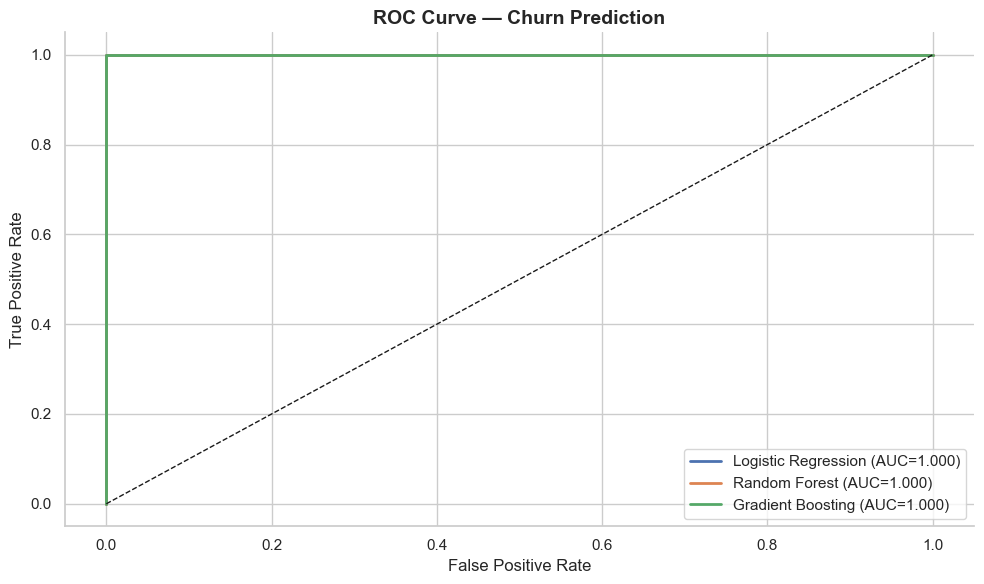

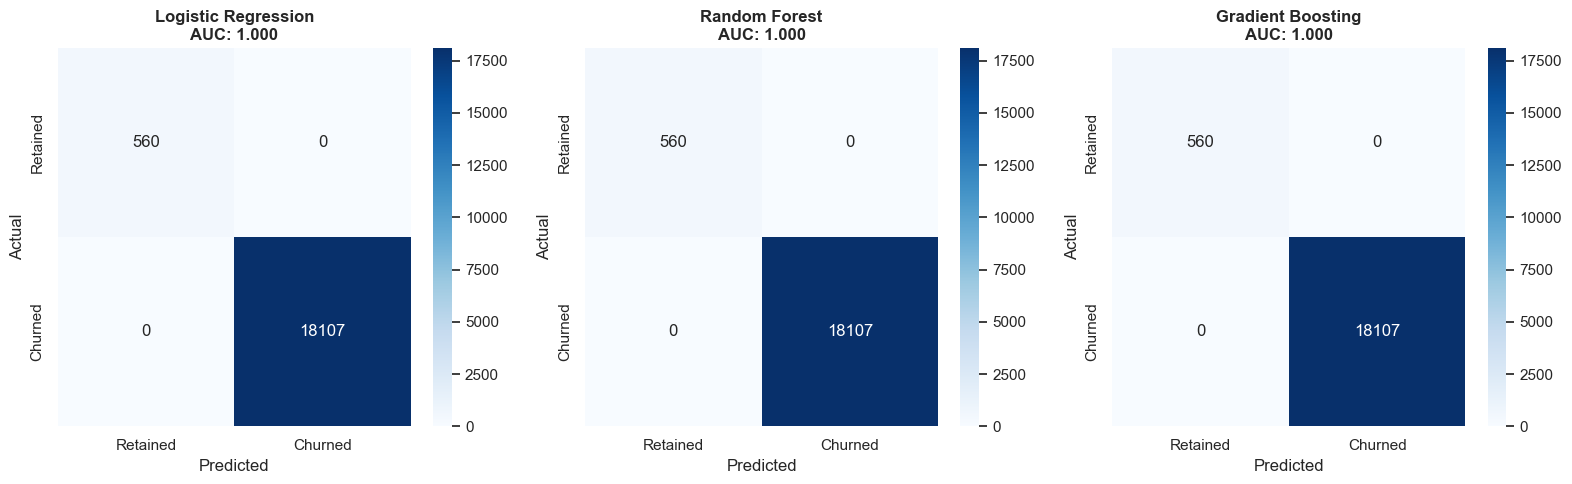

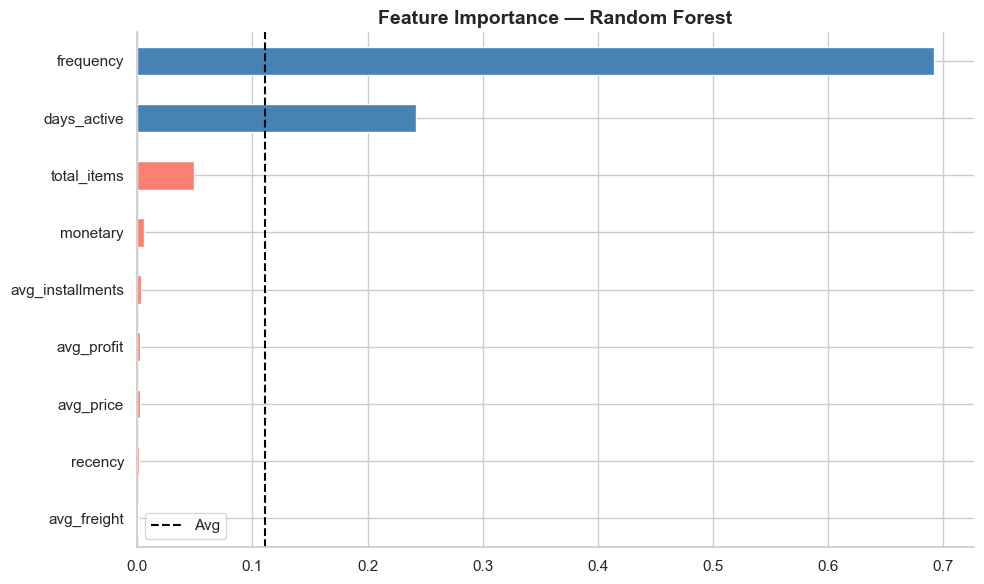

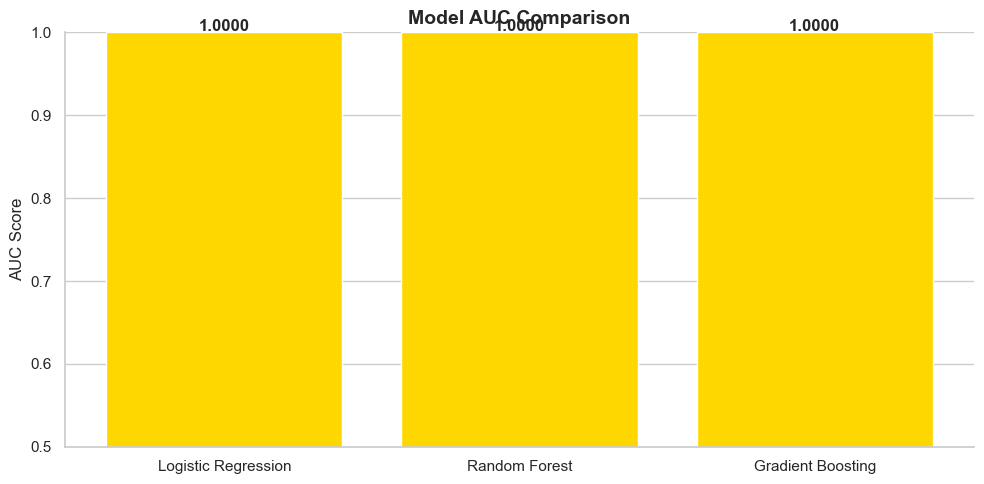

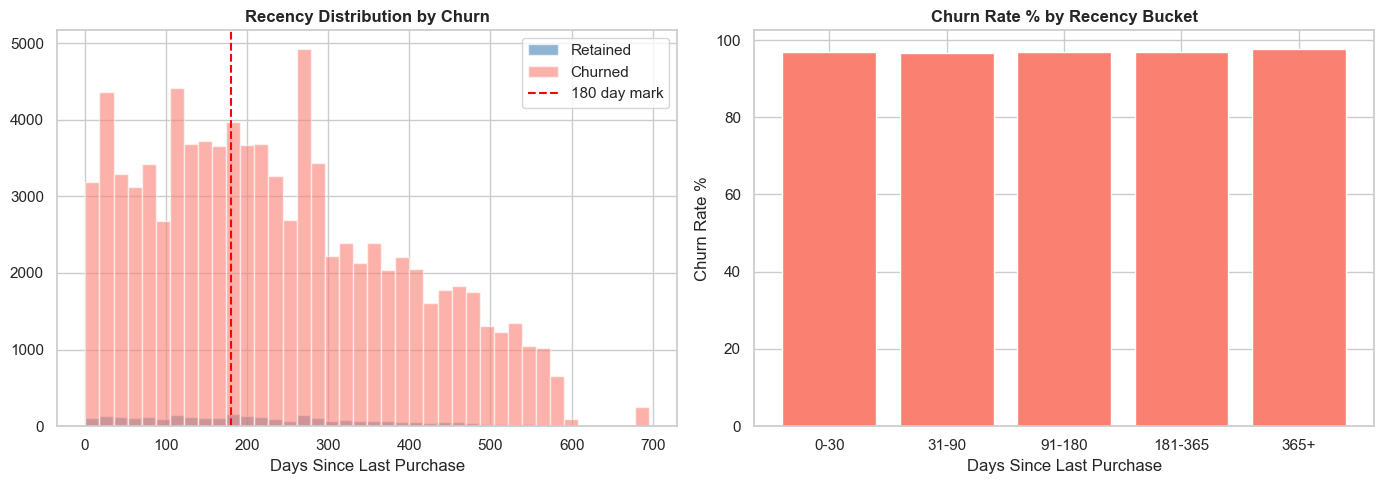

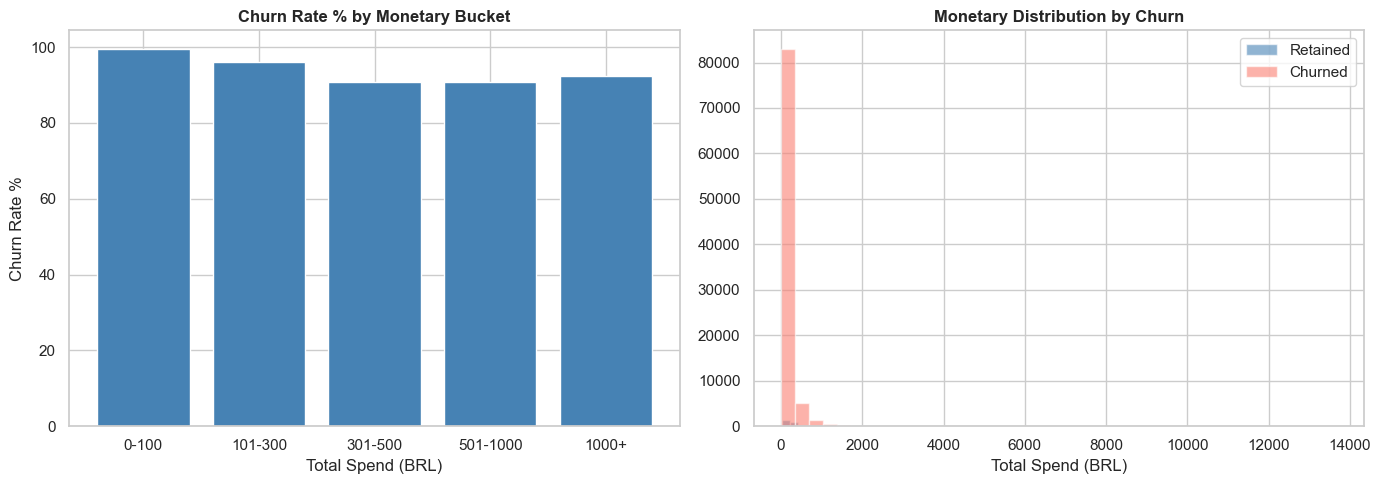

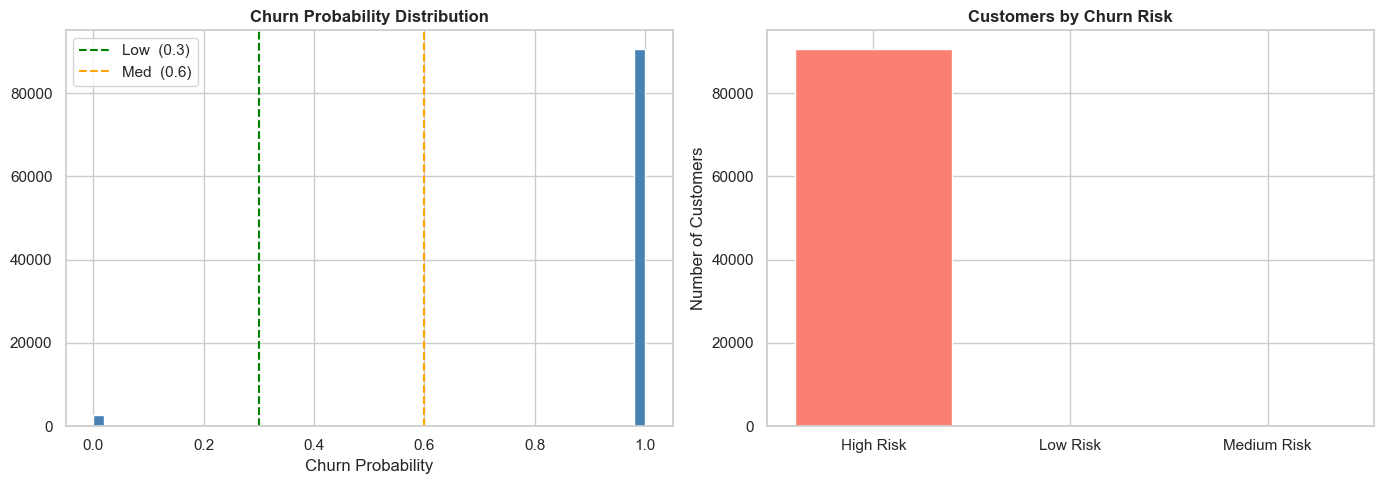

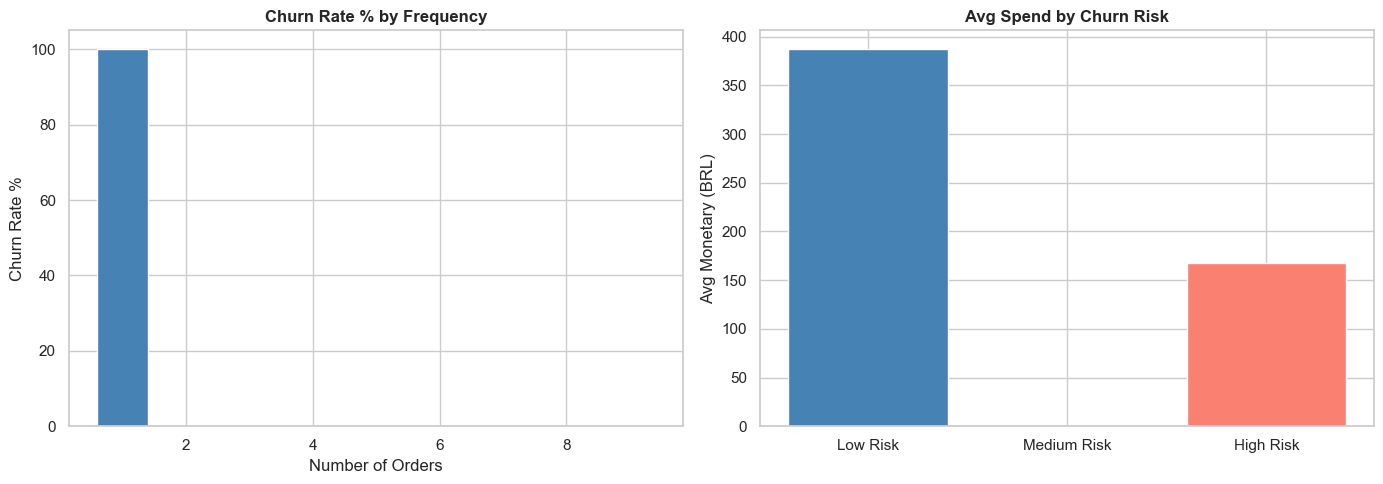


  PIPELINE 1 — DATA LOADED
  df shape        : (115011, 49)
  features shape  : (93335, 13)

  PIPELINE 2 — PREPROCESSING
  Train size      : (74668, 9)
  Test  size      : (18667, 9)

  PIPELINE 3 — MODEL RESULTS
  Logistic Regression       | AUC: 1.0000 | Accuracy: 100.0%
  Random Forest             | AUC: 1.0000 | Accuracy: 100.0%
  Gradient Boosting         | AUC: 1.0000 | Accuracy: 100.0%

  Best Model      : Logistic Regression (AUC=1.0000)

  PIPELINE 5 — PREDICTIONS SAVED
  File            : churn_predictions.csv
  Rows            : 93,335

  PIPELINE 6 — ACCURACY ANALYSIS
  Total Customers : 93,335
  Churned         : 90,535 (97.0%)
  Retained        : 2,800

  Risk Distribution:
    High Risk       : ████████████████████████████████ 90,535 (97.0%)
    Low Risk        :                           237 (0.3%)
    Medium Risk     :                           0 (0.0%)

  Avg Churn Probability by Risk:
churn_risk
Low Risk       0.013
Medium Risk      NaN
High Risk      1.000

  PIPE

In [4]:
# ============================================================
# RUN — SINGLE LINE
# ============================================================
final = run_all(path='./df_final.csv')